In [1]:
import pandas as pd

df = pd.read_json("metrics.json", lines=True)
df

,type,data,metric
0,Metric,"{'name': 'http_reqs', 'type': 'counter', 'cont...",http_reqs
1,Point,"{'time': '2026-03-31T22:02:14.0076397+02:00', ...",http_reqs
2,Metric,"{'name': 'http_req_duration', 'type': 'trend',...",http_req_duration
3,Point,"{'time': '2026-03-31T22:02:14.0076397+02:00', ...",http_req_duration
4,Metric,"{'name': 'http_req_blocked', 'type': 'trend', ...",http_req_blocked
...,...,...,...
25691,Point,"{'time': '2026-03-31T22:04:13.4724521+02:00', ...",checks
25692,Point,"{'time': '2026-03-31T22:04:13.4724521+02:00', ...",data_sent
25693,Point,"{'time': '2026-03-31T22:04:13.4724521+02:00', ...",data_received
25694,Point,"{'time': '2026-03-31T22:04:13.4724521+02:00', ...",iteration_duration


In [2]:
df.columns

Index(['type', 'data', 'metric'], dtype='object')

In [3]:
points = df[df["type"] == "Point"].copy()


In [4]:
import pandas as pd

expanded = pd.json_normalize(points["data"])

In [5]:
expanded["metric"] = points["metric"].values


In [6]:
expanded


,time,value,tags.expected_response,tags.group,tags.method,tags.name,tags.proto,tags.protocol,tags.scenario,tags.status,tags.url,tags.check,metric
0,2026-03-31T22:02:14.0076397+02:00,1.0000,true,,POST,auth_signup,HTTP/1.1,http,stress,201,auth_signup,NaN,http_reqs
1,2026-03-31T22:02:14.0076397+02:00,800.8315,true,,POST,auth_signup,HTTP/1.1,http,stress,201,auth_signup,NaN,http_req_duration
2,2026-03-31T22:02:14.0076397+02:00,2.0182,true,,POST,auth_signup,HTTP/1.1,http,stress,201,auth_signup,NaN,http_req_blocked
3,2026-03-31T22:02:14.0076397+02:00,0.9999,true,,POST,auth_signup,HTTP/1.1,http,stress,201,auth_signup,NaN,http_req_connecting
4,2026-03-31T22:02:14.0076397+02:00,0.0000,true,,POST,auth_signup,HTTP/1.1,http,stress,201,auth_signup,NaN,http_req_tls_handshaking
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25675,2026-03-31T22:04:13.4724521+02:00,1.0000,NaN,,NaN,NaN,NaN,NaN,default,NaN,NaN,storage 200,checks
25676,2026-03-31T22:04:13.4724521+02:00,1108.0000,NaN,,NaN,NaN,NaN,NaN,default,NaN,NaN,NaN,data_sent
25677,2026-03-31T22:04:13.4724521+02:00,1562.0000,NaN,,NaN,NaN,NaN,NaN,default,NaN,NaN,NaN,data_received
25678,2026-03-31T22:04:13.4724521+02:00,374.7787,NaN,,NaN,NaN,NaN,NaN,default,NaN,NaN,NaN,iteration_duration


In [7]:
http_df = expanded[expanded["metric"] == "http_req_duration"].copy()

In [16]:
http_df["value"].max

<bound method Series.max of 1        800.8315
13       720.6149
27       195.0333
37        97.3938
51       221.0875
           ...   
25617      5.2689
25631    377.1201
25641      4.6305
25657    356.3236
25667     16.6711
Name: value, Length: 2120, dtype: float64>

In [9]:
http_df = http_df.dropna(axis=1, how="all").copy()

In [10]:
http_df["time"] = pd.to_datetime(http_df["time"])
http_df = http_df.sort_values("time")

# Convert to seconds relative to first timestamp
http_df["time_sec"] = (http_df["time"] - http_df["time"].min()).dt.total_seconds()

In [11]:
http_df["time"]

1       2026-03-31 22:02:14.007639700+02:00
13      2026-03-31 22:02:14.730539800+02:00
27      2026-03-31 22:02:14.927469500+02:00
37      2026-03-31 22:02:15.025386900+02:00
51      2026-03-31 22:02:15.086506300+02:00
                        ...                
25617   2026-03-31 22:04:12.982409200+02:00
25631   2026-03-31 22:04:13.091822700+02:00
25641   2026-03-31 22:04:13.097014700+02:00
25657      2026-03-31 22:04:13.453997+02:00
25667   2026-03-31 22:04:13.471940100+02:00
Name: time, Length: 2120, dtype: datetime64[ns, UTC+02:00]

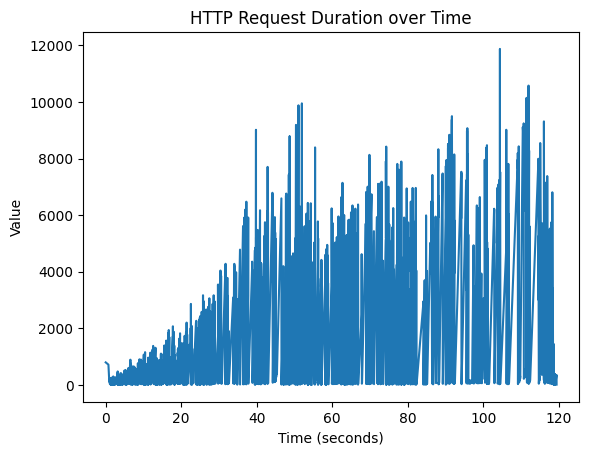

In [12]:
import matplotlib.pyplot as plt

plt.plot(http_df["time_sec"], http_df["value"])
plt.xlabel("Time (seconds)")
plt.ylabel("Value")
plt.title("HTTP Request Duration over Time")
plt.show()

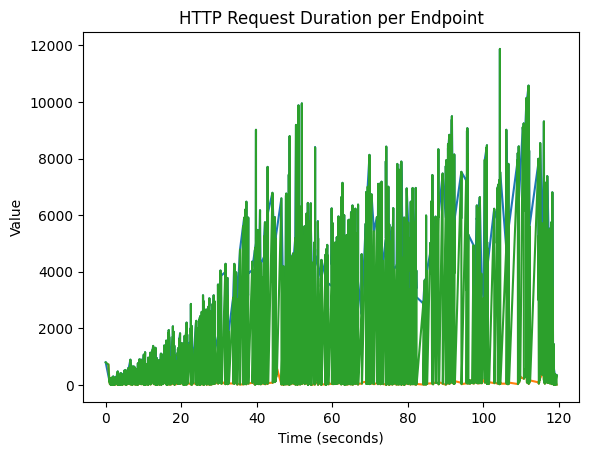

In [13]:
for name, group in http_df.groupby("tags.name"):
    group.set_index("time_sec")["value"].plot(label=name)

plt.plot(http_df["time_sec"], http_df["value"])
plt.xlabel("Time (seconds)")
plt.ylabel("Value")
plt.title("HTTP Request Duration per Endpoint")
plt.show()